In [42]:
import cv2
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [43]:

def kmeans_plus_plus_initialization(data, k):
    """
    k-means++ initialization to choose initial centroids.
    
    Args:
        data (ndarray): Data points (n_samples, n_features).
        k (int): Number of clusters.
    
    Returns:
        centroids (ndarray): Initialized centroids.
    """
    n_samples, _ = data.shape
    centroids = []

    # Step 1: Randomly choose the first centroid
    centroids.append(data[np.random.randint(0, n_samples)])

    # Step 2: Choose remaining centroids
    for _ in range(1, k):
        # Compute distances from each point to the closest centroid
        distances = np.min(euclidean_distances(data, np.array(centroids)), axis=1)
        probabilities = distances**2 / np.sum(distances**2)
        cumulative_probabilities = np.cumsum(probabilities)

        # Select the next centroid based on weighted probability
        r = np.random.rand()
        next_centroid_index = np.searchsorted(cumulative_probabilities, r)
        centroids.append(data[next_centroid_index])

    return np.array(centroids)


def balanced_k_means(data, k, cluster_size, max_iter=100, num_initializations=10):
    """
    Perform Balanced K-means clustering with k-means++ initialization.
    
    Args:
        data (ndarray): Data points (n_samples, n_features).
        k (int): Number of clusters.
        cluster_size (int): Desired size of each cluster.
        max_iter (int): Maximum number of iterations for a single initialization.
        num_initializations (int): Number of initializations to try.
    
    Returns:
        best_labels (ndarray): Cluster labels for each data point.
        best_centroids (ndarray): Final centroids with the lowest inertia.
        best_inertia (float): Minimum inertia achieved.
    """
    n_samples, n_features = data.shape
    assert n_samples == k * cluster_size, "Number of samples must be divisible by cluster size."

    best_inertia = np.inf
    best_labels = None
    best_centroids = None

    for init in range(num_initializations):
        # Use k-means++ initialization for centroids
        centroids = kmeans_plus_plus_initialization(data, k)
        labels = np.zeros(n_samples, dtype=int)

        for iteration in range(max_iter):
            # Compute distances from points to centroids
            distances = euclidean_distances(data, centroids)

            # Assign points to clusters while enforcing balance
            sorted_indices = np.argsort(distances, axis=0)
            clusters = [[] for _ in range(k)]
            assigned = set()

            for i in range(k):  # For each cluster
                for idx in sorted_indices[:, i]:
                    if len(clusters[i]) < cluster_size and idx not in assigned:
                        clusters[i].append(idx)
                        assigned.add(idx)

            # Update centroids
            new_centroids = np.array([data[cluster].mean(axis=0) for cluster in clusters])

            # Check for convergence
            if np.allclose(centroids, new_centroids, atol=1e-6):
                break
            centroids = new_centroids

        # Compute inertia for the current initialization
        inertia = sum(
            np.sum(euclidean_distances(data[cluster], centroids[i].reshape(1, -1))**2)
            for i, cluster in enumerate(clusters)
        )

        # Update best solution if this is the best inertia so far
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = np.zeros(n_samples, dtype=int)
            for cluster_idx, cluster in enumerate(clusters):
                for idx in cluster:
                    best_labels[idx] = cluster_idx
            best_centroids = centroids

    return best_labels, best_centroids, best_inertia


In [44]:

# Function to draw a smaller, centered 3x3 grid on an image
def draw_centered_grid(image, grid_size=200):
    h, w, _ = image.shape
    center_x, center_y = w // 2, h // 2

    # Calculate the grid boundaries
    half_size = grid_size // 2
    top_left_x, top_left_y = center_x - half_size, center_y - half_size
    bottom_right_x, bottom_right_y = center_x + half_size, center_y + half_size

    # Draw the grid
    cell_size = grid_size // 3
    for i in range(4):
        y = top_left_y + i * cell_size
        x = top_left_x + i * cell_size
        cv2.line(image, (top_left_x, y), (bottom_right_x, y), (255, 255, 255), 2)
        cv2.line(image, (x, top_left_y), (x, bottom_right_y), (255, 255, 255), 2)

    return image, (top_left_x, top_left_y, cell_size)


# Function to detect the dominant color in a square
def detect_dominant_color(square, neighborhood_fraction=0.5, blur_ksize=5):
    h, w, _ = square.shape
    center_x, center_y = w // 2, h // 2

    # Define the neighborhood size
    offset_x = int(w * neighborhood_fraction // 2)
    offset_y = int(h * neighborhood_fraction // 2)

    # Extract the neighborhood region
    neighborhood = square[center_y - offset_x:center_y + offset_x, center_x - offset_y:center_x + offset_y]

    # Apply Gaussian blur to the neighborhood
    blurred = cv2.GaussianBlur(neighborhood, (blur_ksize, blur_ksize), 0)

    # Calculate the average color in the blurred neighborhood
    avg_color = blurred.mean(axis=0).mean(axis=0)
    return tuple(map(int, avg_color))  # Convert to (B, G, R)


# Initialize webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

captured_faces = []  # List to store captured face images
color_data = []  # List to store color data for each face
capture_limit = 6  # Number of faces to capture

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame.")
        break

    # Draw the smaller, centered 3x3 grid on the frame
    grid_frame, grid_info = draw_centered_grid(frame.copy(), grid_size=200)

    # Display the live webcam feed with the smaller grid overlay
    cv2.imshow('Align Your Cube and Press Space', grid_frame)

    key = cv2.waitKey(1)

    if key == ord('q') or key == 27:  # Quit on 'q' or 'Esc'
        break
    elif key == ord(' '):  # Capture on spacebar
        if len(captured_faces) < capture_limit:
            captured_faces.append(frame.copy())
            print(f"Captured face {len(captured_faces)}")

            # Analyze grid colors
            top_left_x, top_left_y, cell_size = grid_info
            colors = []
            for i in range(3):
                for j in range(3):
                    x1 = top_left_x + j * cell_size
                    y1 = top_left_y + i * cell_size
                    x2 = x1 + cell_size
                    y2 = y1 + cell_size
                    square = frame[y1:y2, x1:x2]
                    dominant_color = detect_dominant_color(square)
                    colors.append(dominant_color)
            color_data.append(colors)
        else:
            print("All 6 faces have already been captured!")

    # Check if all faces are captured
    if len(captured_faces) == capture_limit:
        break

cap.release()
cv2.destroyAllWindows()

print(color_data)
# Display the final color palette
if len(color_data) == capture_limit:
    # Create a blank canvas for the color palette
    palette_height = 300
    palette_width = 600
    palette = np.zeros((palette_height, palette_width, 3), dtype=np.uint8)

    face_width = palette_width // 6  # Width of each face in the palette
    cell_size = face_width // 3     # Size of each cell within a face

    for face_idx, face_colors in enumerate(color_data):
        for i in range(3):
            for j in range(3):
                color = face_colors[i * 3 + j]
                top_left_x = face_idx * face_width + j * cell_size
                top_left_y = i * cell_size
                bottom_right_x = top_left_x + cell_size
                bottom_right_y = top_left_y + cell_size
                cv2.rectangle(
                    palette,
                    (top_left_x, top_left_y),
                    (bottom_right_x, bottom_right_y),
                    color,  # Convert BGR to RGB for OpenCV
                    -1  # Filled rectangle
                )

    # Show the color palette
    cv2.imshow('Cube Color Palette', palette)

    # Wait for user input to close the window
    print("Press any key in the 'Cube Color Palette' window to close.")
    while True:
        if cv2.waitKey(1) & 0xFF in {ord('q'), 27}:  # Quit on 'q' or 'Esc'
            break

    # Destroy the palette window
    cv2.destroyAllWindows()

Captured face 1
Captured face 2
Captured face 3
Captured face 4
Captured face 5
Captured face 6
[[(9, 114, 110), (8, 92, 23), (21, 8, 173), (9, 102, 23), (63, 60, 65), (23, 9, 192), (47, 14, 18), (14, 112, 27), (19, 8, 103)], [(7, 117, 98), (13, 5, 82), (37, 10, 15), (19, 10, 100), (29, 15, 190), (12, 97, 35), (20, 113, 33), (35, 23, 191), (52, 17, 28)], [(28, 14, 178), (2, 108, 104), (5, 96, 19), (43, 14, 19), (9, 105, 24), (103, 99, 108), (111, 108, 115), (113, 113, 114), (37, 26, 203)], [(15, 97, 24), (23, 13, 165), (91, 89, 96), (41, 15, 19), (14, 5, 90), (99, 95, 98), (6, 130, 112), (5, 131, 108), (17, 8, 93)], [(9, 111, 114), (24, 11, 184), (94, 91, 97), (16, 9, 86), (45, 14, 19), (2, 121, 98), (110, 107, 115), (9, 131, 125), (52, 17, 22)], [(20, 9, 90), (14, 4, 100), (6, 99, 19), (52, 21, 25), (13, 133, 114), (47, 16, 20), (35, 21, 201), (117, 115, 123), (24, 11, 106)]]
Press any key in the 'Cube Color Palette' window to close.


In [45]:
# Example data in BGR format
lab_data_bgr = np.array(color_data)

# Flatten the data to a 2D array of shape (n_samples, 3)
lab_data_bgr_flat = lab_data_bgr.reshape(-1, 3).astype(np.uint8)

# Convert from BGR to LAB using OpenCV
# Reshape the data into a proper image format for color conversion
lab_data_bgr_image = lab_data_bgr_flat.reshape(lab_data_bgr.shape[0], lab_data_bgr.shape[1], 3)  # reshape to (height, width, 3)

lab_data_lab = cv2.cvtColor(lab_data_bgr_image, cv2.COLOR_BGR2LAB)

# Now `lab_data_lab` contains the data in LAB color space
print(lab_data_lab)

k = 6
cluster_size = 9


# Flatten `lab_data` into a 2D array
lab_data_flat = np.array(lab_data_lab).reshape(-1, 3)

# Perform Balanced K-means
labels, centroids, inertia = balanced_k_means(lab_data_flat, k, cluster_size, 100, 1000)

# Print results
print("Cluster Labels:", labels)
print("Centroids in LAB:", centroids)
print("Inertia:", inertia)

[[[118 115 178]
  [ 86  91 165]
  [ 92 187 170]
  [ 95  87 168]
  [ 66 131 127]
  [103 192 174]
  [ 15 141 107]
  [105  85 171]
  [ 52 168 150]]

 [[118 107 178]
  [ 38 162 146]
  [ 10 138 111]
  [ 51 166 150]
  [103 191 170]
  [ 91  92 166]
  [106  86 169]
  [104 190 168]
  [ 20 144 107]]

 [[ 96 188 167]
  [112 115 178]
  [ 89  88 168]
  [ 15 138 110]
  [ 98  87 169]
  [109 132 127]
  [118 131 127]
  [122 129 128]
  [111 193 170]]

 [[ 91  90 165]
  [ 88 184 167]
  [ 98 131 128]
  [ 15 138 111]
  [ 43 165 148]
  [104 130 126]
  [131 107 182]
  [131 105 182]
  [ 46 164 149]]

 [[116 118 177]
  [ 99 190 171]
  [100 131 127]
  [ 42 162 146]
  [ 15 139 108]
  [121 105 180]
  [117 132 127]
  [134 112 183]
  [ 18 142 105]]

 [[ 45 163 146]
  [ 49 168 151]
  [ 92  88 168]
  [ 23 141 108]
  [133 106 182]
  [ 17 139 108]
  [109 193 170]
  [126 132 128]
  [ 55 168 148]]]
Cluster Labels: [4 1 0 1 3 0 2 1 5 4 5 2 5 0 1 1 0 2 0 4 1 2 1 3 3 3 0 1 0 3 2 5 3 4 4 5 4
 0 3 5 2 4 3 4 2 5 5 1 2 4 2 0 3 

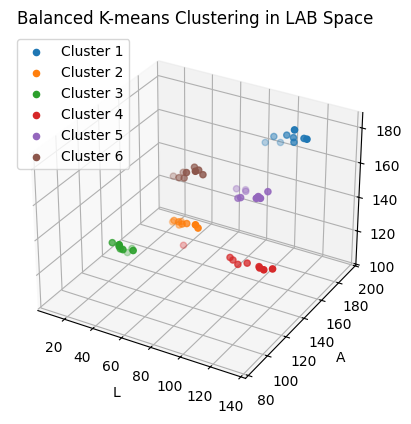

In [46]:
# Convert centroids back to BGR for visualization
bgr_centroids = np.array([cv2.cvtColor(np.uint8([[lab]]), cv2.COLOR_Lab2BGR)[0][0] for lab in centroids])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for i in range(k):
    cluster_points = lab_data_flat[labels == i]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], label=f"Cluster {i+1}")

ax.set_xlabel('L')
ax.set_ylabel('A')
ax.set_zlabel('B')
ax.legend()
plt.title("Balanced K-means Clustering in LAB Space")
plt.show()

In [47]:
# Flatten lab_data for easier processing with labels
lab_data_flat = np.array(lab_data_lab).reshape(-1, 3)

# Print the indices of items in each cluster
print("Clusters and their indices in the original data list:")

for i in range(k):
    # Find the indices of items belonging to the current cluster
    cluster_indices = np.where(labels == i)[0]  # Indices in the flattened array
    print(f"\nCluster {i+1} (Total points: {len(cluster_indices)}):")
    print(cluster_indices)


Clusters and their indices in the original data list:

Cluster 1 (Total points: 9):
[ 2  5 13 16 18 26 28 37 51]

Cluster 2 (Total points: 9):
[ 1  3  7 14 15 20 22 27 47]

Cluster 3 (Total points: 9):
[ 6 11 17 21 30 40 44 48 50]

Cluster 4 (Total points: 9):
[ 4 23 24 25 29 32 38 42 52]

Cluster 5 (Total points: 9):
[ 0  9 19 33 34 36 41 43 49]

Cluster 6 (Total points: 9):
[ 8 10 12 31 35 39 45 46 53]


In [48]:
# Define cluster-to-color mapping
centre_indices = [4, 22, 13, 31, 40, 49]
picture_order = [0, 2, 1, 3, 4, 5]
color_order = ['W', 'G', 'O', 'R', 'B', 'Y']
cluster_to_color = {}
for i in range(6):
    cluster_to_color[labels[centre_indices[i]]] = color_order[i]

# Example: Assuming `labels` contains the cluster labels for all 54 facelets
# Convert cluster labels to their respective colors


facelet_colors = [cluster_to_color[label] for label in labels]

# Reshape to a 6x9 array (6 faces, each with 9 facelets)
facelet_array = np.array(facelet_colors).reshape(6, 9)

new_facelet_array = [facelet_array[picture_order[i]] for i in range(6)]
facelet_array = np.array(new_facelet_array)

# Concatenate the facelets into a single string (row-wise for each face)
facelet_string = ''.join(facelet_array.flatten())

# Print the single-string representation
print("Facelet String Representation:")
print(facelet_string)

Facelet String Representation:
YGOGWOBGROYGBGWWWOYRBROGGOBGOWBRWYYRYOWRBYWYBRRGBYBOWR


White with orangeg on top
orange with green on top
rotate round to blue keeping white on top
then yellow with blue on top